# AutoEncoders

In [35]:
from tensorflow.datasets import fashion_mnist
from tensorflow.keras import layers, Sequential, optimizers, metrics, activations
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.manifold import TSNE

sns.set_style('whitegrid')

# PCA with a linear Autoencoder

In [2]:
# Build 3D dataset:

np.random.seed(4)

def generate_3d_data(m, w1=0.1, w2=0.3, noise=0.1):
    angles = np.random.rand(m) * 3 * np.pi / 2 - 0.5
    data = np.empty((m, 3))
    data[:, 0] = np.cos(angles) + np.sin(angles)/2 + noise * np.random.randn(m) / 2
    data[:, 1] = np.sin(angles) * 0.7 + noise * np.random.randn(m) / 2
    data[:, 2] = data[:, 0] * w1 + data[:, 1] * w2 + noise * np.random.randn(m)
    return data

X_train = generate_3d_data(60)
X_train = X_train - X_train.mean(axis=0, keepdims=0)

In [5]:
encoder = Sequential([
    layers.Input(shape=(3,)),
    layers.Dense(2, activation='relu'),
])

decoder = Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(3, activation='sigmoid'),
])

autoencoder = Sequential([encoder, decoder])

autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=32)
codings = encoder.predict(X_train)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.5410
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.5402 
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.5393
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.5385
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.5376 
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.5368 
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.5359
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.5350 
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.5341
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.5331
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.5321 
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.5313 
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.5303
Epoch 14/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.5293 
Epoch 15/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.5284
Epoch 16/50
2/2 ━━━━━━━━━━━

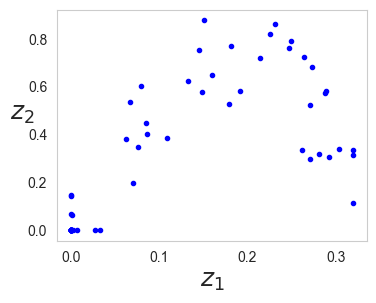

In [11]:
fig = plt.figure(figsize=(4,3))
plt.plot(codings[:,0], codings[:, 1], "b.")
plt.xlabel("$z_1$", fontsize=18)
plt.ylabel("$z_2$", fontsize=18, rotation=0)
plt.grid(False)
# save_fig("linear_autoencoder_pca_plot")
plt.show()

# Multi-layer AutoEncoder

In [14]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [19]:
def rounded_accuracy(y_true, y_pred):
    return metrics.binary_accuracy(tf.round(y_true), tf.round(y_pred))

In [27]:
stacked_encoder = Sequential([
    layers.Input(shape=(28,28)),
    layers.Flatten(),
    layers.Dense(100, activation='selu'),
    layers.Dense(30, activation='selu'),
])

stacked_decoder = Sequential([
    layers.Input(shape=(30,)),
    layers.Dense(100, activation='selu'),
    layers.Dense(28*28, activation='sigmoid'),
    layers.Reshape((28,28)),
])

stacked_ae = Sequential([stacked_encoder, stacked_decoder])

stacked_ae.compile(loss="binary_crossentropy",
                   optimizer=optimizers.SGD(learning_rate=1.5), metrics=[rounded_accuracy])
history = stacked_ae.fit(X_train, X_train, epochs=10,
                         validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3367 - rounded_accuracy: 0.8881 - val_loss: 0.3134 - val_rounded_accuracy: 0.9068
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3061 - rounded_accuracy: 0.9146 - val_loss: 0.3027 - val_rounded_accuracy: 0.9192
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2993 - rounded_accuracy: 0.9208 - val_loss: 0.2986 - val_rounded_accuracy: 0.9252
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2951 - rounded_accuracy: 0.9245 - val_loss: 0.2953 - val_rounded_accuracy: 0.9240
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2927 - rounded_accuracy: 0.9267 - val_loss: 0.2932 - val_rounded_accuracy: 0.9279
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2909 - rounded_accuracy: 0.9283 - val_loss: 0.2911 - val_rounded_accuracy: 0.9305
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2895 - rounded_accuracy: 0.9295 - val_loss: 0.2903 - val_rou

# Result Visualization

In [28]:
def plot_image(image):
    plt.imshow(image, cmap='gray')
    plt.axis('off')

def show_reconstructions(model, images=X_valid, n_images=15):
    reconstructions = model.predict(images[:n_images])
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plot_image(images[image_index])
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plot_image(reconstructions[image_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


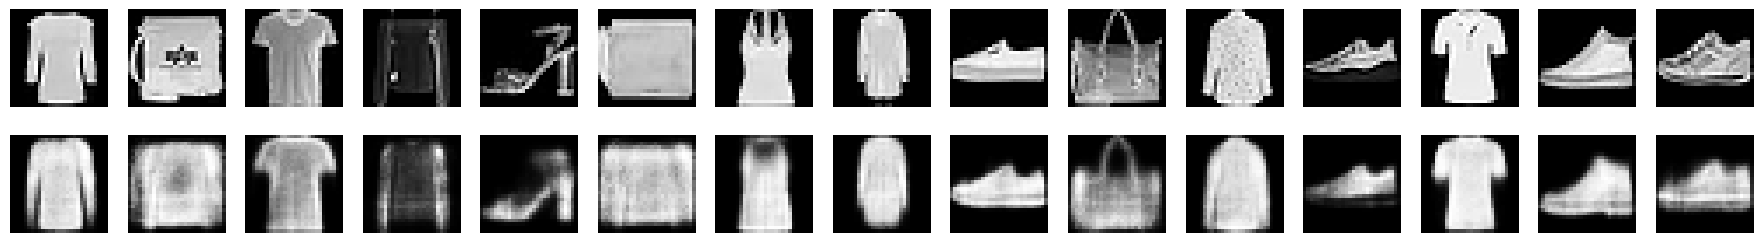

In [29]:
show_reconstructions(stacked_ae)

# Visualizing Fashion MNIST

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


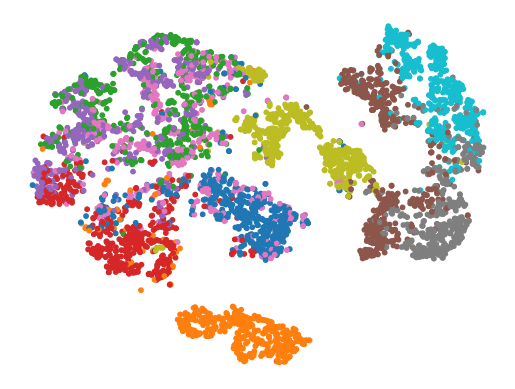

In [31]:
np.random.seed(42)

X_valid_compressed = stacked_encoder.predict(X_valid)
tsne = TSNE()
X_valid_2D = tsne.fit_transform(X_valid_compressed)
X_valid_2D = (X_valid_2D - X_valid_2D.min()) / (X_valid_2D.max() - X_valid_2D.min())
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap="tab10")
plt.axis("off")
plt.show()

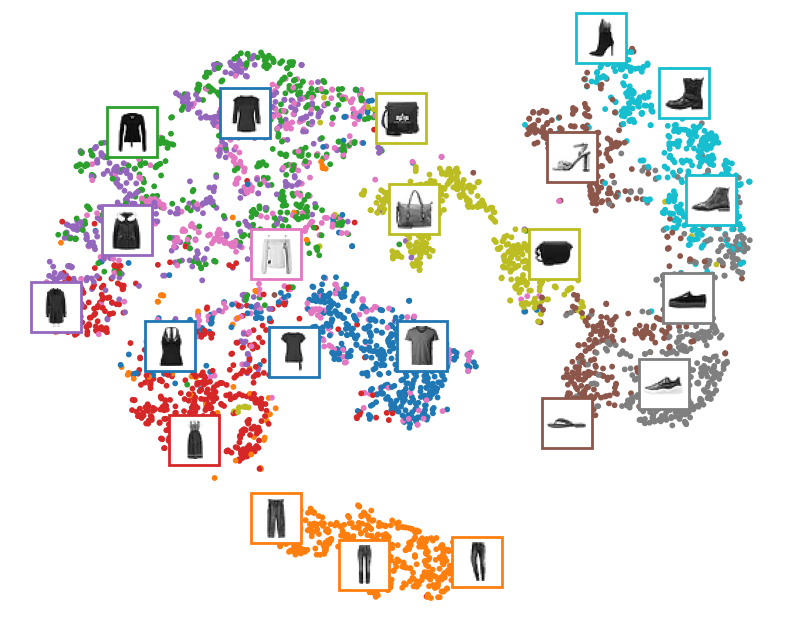

In [34]:
# Let's make this diagram a bit prettier:

# adapted from https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html
plt.figure(figsize=(10, 8))
cmap = plt.cm.tab10
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap=cmap)
image_positions = np.array([[1., 1.]])
for index, position in enumerate(X_valid_2D):
    dist = np.sum((position - image_positions) ** 2, axis=1)
    if np.min(dist) > 0.02: # if far enough from other images
        image_positions = np.r_[image_positions, [position]]
        imagebox = mpl.offsetbox.AnnotationBbox(
            mpl.offsetbox.OffsetImage(X_valid[index], cmap="binary"),
            position, bboxprops={"edgecolor": cmap(y_valid[index]), "lw": 2})
        plt.gca().add_artist(imagebox)
plt.axis("off")
plt.show()

# Tying weights
It is common to tie the weights of the encoder and the decoder, by simply using the transpose of the encoder's weights as the decoder weights. For this, we need to use a custom layer.

In [40]:
class DenseTranspose(layers.Layer):
    def __init__(self, dense, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.dense = dense
        self.activation = activations.get(activation)

    def build(self, batch_input_shape):
        # kernel shape: (input_dim, output_dim)
        input_dim = int(self.dense.kernel.shape[0])
        self.biases = self.add_weight(
            name="bias",
            shape=(input_dim,),
            initializer="zeros",
            trainable=True,
        )
        super().build(batch_input_shape)

    def call(self, inputs):
        # transpose of encoder weights
        z = tf.matmul(inputs, self.dense.kernel, transpose_b=True)
        z = z + self.biases
        if self.activation is not None:
            z = self.activation(z)
        return z

In [41]:
tf.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

dense_1 = layers.Dense(100, activation="selu")
dense_2 = layers.Dense(30, activation="selu")

tied_encoder = Sequential([
    layers.Input(shape=(28,28)),
    layers.Flatten(),
    dense_1,
    dense_2
])

tied_decoder = Sequential([
    DenseTranspose(dense_2, activation="selu"),
    DenseTranspose(dense_1, activation="sigmoid"),
    layers.Reshape([28, 28])
])

tied_ae = Sequential([tied_encoder, tied_decoder])

tied_ae.compile(loss="binary_crossentropy",
                optimizer=optimizers.SGD(learning_rate=1.5), metrics=[rounded_accuracy])
history = tied_ae.fit(X_train, X_train, epochs=10,
                      validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.3272 - rounded_accuracy: 0.8956 - val_loss: 0.3058 - val_rounded_accuracy: 0.9105
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2975 - rounded_accuracy: 0.9222 - val_loss: 0.2984 - val_rounded_accuracy: 0.9171
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.2914 - rounded_accuracy: 0.9281 - val_loss: 0.2904 - val_rounded_accuracy: 0.9311
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.2882 - rounded_accuracy: 0.9311 - val_loss: 0.2882 - val_rounded_accuracy: 0.9330
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.2861 - rounded_accuracy: 0.9330 - val_loss: 0.2868 - val_rounded_accuracy: 0.9339
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.2846 - rounded_accuracy: 0.9344 - val_loss: 0.2855 - val_rounded_accuracy: 0.9355
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2835 - rounded_accuracy: 0.9354 - val_loss: 0.2845 - val_r

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


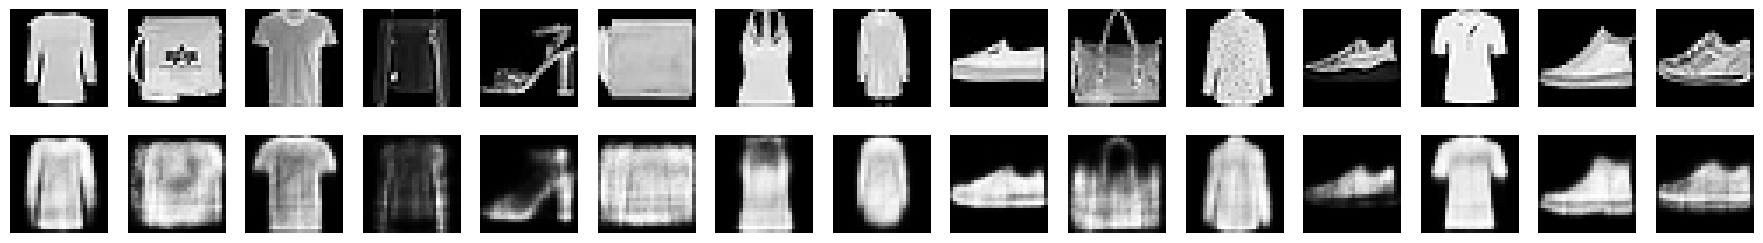

In [42]:
show_reconstructions(tied_ae)
plt.show()

# Training one Autoencoder at a Time

In [43]:
def train_autoencoder(n_neurons, X_train, X_valid, loss, optimizer,
                      n_epochs=10, output_activation=None, metrics=None):
    n_inputs = X_train.shape[-1]
    encoder = Sequential([
        layers.Input(shape=[n_inputs])
        layers.Dense(n_neurons, activation="selu")
    ])
    decoder = Sequential([
        layers.Dense(n_inputs, activation=output_activation),
    ])
    autoencoder = Sequential([encoder, decoder])
    autoencoder.compile(optimizer, loss, metrics=metrics)
    autoencoder.fit(X_train, X_train, epochs=n_epochs,
                    validation_data=(X_valid, X_valid))
    return encoder, decoder, encoder(X_train), encoder(X_valid)

In [44]:
tf.random.set_seed(42)
np.random.seed(42)

K = tf.backend
X_train_flat = K.batch_flatten(X_train) # equivalent to .reshape(-1, 28 * 28)
X_valid_flat = K.batch_flatten(X_valid)

enc1, dec1, X_train_enc1, X_valid_enc1 = train_autoencoder(
    100, X_train_flat, X_valid_flat, "binary_crossentropy",
    optimizers.SGD(learning_rate=1.5), output_activation="sigmoid",
    metrics=[rounded_accuracy])
enc2, dec2, _, _ = train_autoencoder(
    30, X_train_enc1, X_valid_enc1, "mse", optimizers.SGD(learning_rate=0.05),
    output_activation="selu")

Epoch 1/10


C:\Users\Tymur_Hilfatullin\Projects\ML\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3445 - rounded_accuracy: 0.8875 - val_loss: 0.3121 - val_rounded_accuracy: 0.9148
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3039 - rounded_accuracy: 0.9204 - val_loss: 0.3009 - val_rounded_accuracy: 0.9240
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2954 - rounded_accuracy: 0.9282 - val_loss: 0.2940 - val_rounded_accuracy: 0.9307
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2897 - rounded_accuracy: 0.9336 - val_loss: 0.2895 - val_rounded_accuracy: 0.9352
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2860 - rounded_accuracy: 0.9372 - val_loss: 0.2865 - val_rounded_accuracy: 0.9382
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2835 - rounded_accuracy: 0.9397 - val_loss: 0.2843 - val_rounded_accuracy: 0.9404
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2815 - rounded_accuracy: 0.9416 - val_loss: 0.2825 - val_rounded_accura

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


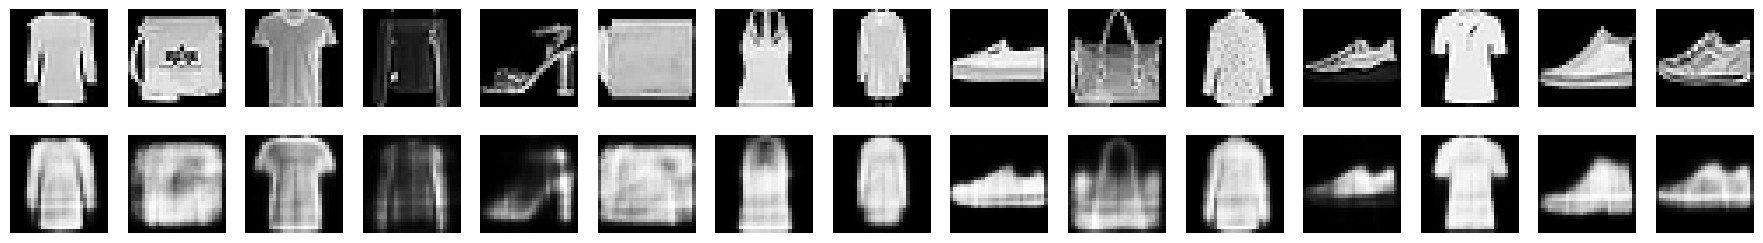

In [46]:
stacked_ae_1_by_1 = Sequential([
    layers.Flatten(input_shape=[28, 28]),
    enc1, enc2, dec2, dec1,
    layers.Reshape([28, 28])
])
show_reconstructions(stacked_ae_1_by_1)
plt.show()

In [47]:
stacked_ae_1_by_1.compile(loss="binary_crossentropy",
                          optimizer=optimizers.SGD(learning_rate=0.1),
                          metrics=[rounded_accuracy])

history = stacked_ae_1_by_1.fit(X_train, X_train, epochs=10,
                                validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.2861 - rounded_accuracy: 0.9350 - val_loss: 0.2878 - val_rounded_accuracy: 0.9353
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2858 - rounded_accuracy: 0.9354 - val_loss: 0.2875 - val_rounded_accuracy: 0.9355
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2856 - rounded_accuracy: 0.9356 - val_loss: 0.2874 - val_rounded_accuracy: 0.9357
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2854 - rounded_accuracy: 0.9358 - val_loss: 0.2872 - val_rounded_accuracy: 0.9358
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.2853 - rounded_accuracy: 0.9359 - val_loss: 0.2871 - val_rounded_accuracy: 0.9360
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2852 - rounded_accuracy: 0.9360 - val_loss: 0.2870 - val_rounded_accuracy: 0.9361
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2850 - rounded_accuracy: 0.9361 - val_loss: 0.2869 - val_r

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


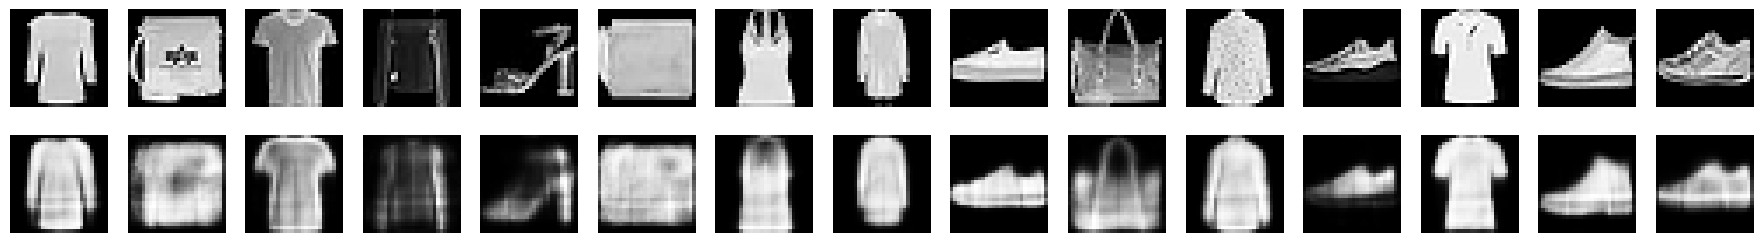

In [48]:
show_reconstructions(stacked_ae_1_by_1)
plt.show()

# Using Convolutional Layers Instead of Dense Layers

In [49]:
tf.random.set_seed(42)
np.random.seed(42)

conv_encoder = Sequential([
    layers.Input(shape=[28, 28]),
    layers.Reshape([28, 28, 1]),
    layers.Conv2D(16, kernel_size=3, padding="SAME", activation="selu"),
    layers.MaxPool2D(pool_size=2),
    layers.Conv2D(32, kernel_size=3, padding="SAME", activation="selu"),
    layers.MaxPool2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, padding="SAME", activation="selu"),
    layers.MaxPool2D(pool_size=2)
])
conv_decoder = Sequential([
    layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding="VALID", activation="selu",
                                 input_shape=[3, 3, 64]),
    layers.Conv2DTranspose(16, kernel_size=3, strides=2, padding="SAME", activation="selu"),
    layers.Conv2DTranspose(1, kernel_size=3, strides=2, padding="SAME", activation="sigmoid"),
    layers.Reshape([28, 28])
])
conv_ae = Sequential([conv_encoder, conv_decoder])

conv_ae.compile(loss="binary_crossentropy", optimizer=optimizers.SGD(learning_rate=1.0),
                metrics=[rounded_accuracy])

history = conv_ae.fit(X_train, X_train, epochs=5,
                      validation_data=(X_valid, X_valid))

C:\Users\Tymur_Hilfatullin\Projects\ML\.venv\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Tymur_Hilfatullin\Projects\ML\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - loss: 0.3004 - rounded_accuracy: 0.9202 - val_loss: 0.2814 - val_rounded_accuracy: 0.9393
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 0.2756 - rounded_accuracy: 0.9415 - val_loss: 0.2750 - val_rounded_accuracy: 0.9425
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.2711 - rounded_accuracy: 0.9461 - val_loss: 0.2715 - val_rounded_accuracy: 0.9464
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.2686 - rounded_accuracy: 0.9487 - val_loss: 0.2688 - val_rounded_accuracy: 0.9494
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 0.2669 - rounded_accuracy: 0.9505 - val_loss: 0.2671 - val_rounded_accuracy: 0.9515


In [50]:
conv_encoder.summary()
conv_decoder.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,296 (91.00 KB)

 Trainable params: 23,296 (91.00 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose                │ (None, 7, 7, 32)       │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           145 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,233 (90.75 KB)

 Trainable params: 23,233 (90.75 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


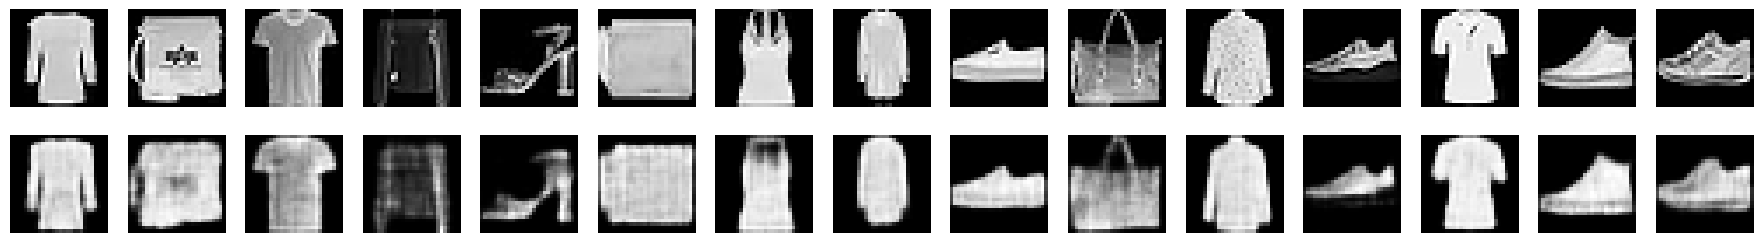

In [51]:
show_reconstructions(conv_ae)
plt.show()

# Recurrent Autoencoders

In [52]:
recurrent_encoder = Sequential([
    layers.Input(shape=[28, 28]),
    layers.LSTM(100, return_sequences=True),
    layers.LSTM(30)
])

recurrent_decoder = Sequential([
    layers.Input(shape=[30]),
    layers.RepeatVector(28),
    layers.LSTM(100, return_sequences=True),
    layers.TimeDistributed(layers.Dense(28, activation="sigmoid"))
])

recurrent_ae = Sequential([recurrent_encoder, recurrent_decoder])

recurrent_ae.compile(loss="binary_crossentropy",
                     optimizer=optimizers.SGD(0.1),
                     metrics=[rounded_accuracy])

history = recurrent_ae.fit(X_train, X_train,
                           epochs=10,
                           validation_data=(X_valid, X_valid))

C:\Users\Tymur_Hilfatullin\Projects\ML\.venv\Lib\site-packages\keras\src\layers\reshaping\repeat_vector.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 102s 50ms/step - loss: 0.5001 - rounded_accuracy: 0.7657 - val_loss: 0.4315 - val_rounded_accuracy: 0.8152
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 79s 46ms/step - loss: 0.3939 - rounded_accuracy: 0.8489 - val_loss: 0.3746 - val_rounded_accuracy: 0.8650
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 64s 37ms/step - loss: 0.3631 - rounded_accuracy: 0.8725 - val_loss: 0.3587 - val_rounded_accuracy: 0.8767
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - loss: 0.3506 - rounded_accuracy: 0.8816 - val_loss: 0.3477 - val_rounded_accuracy: 0.8857
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 126s 73ms/step - loss: 0.3395 - rounded_accuracy: 0.8886 - val_loss: 0.3351 - val_rounded_accuracy: 0.8918
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 122s 71ms/step - loss: 0.3321 - rounded_accuracy: 0.8933 - val_loss: 0.3374 - val_rounded_accuracy: 0.8931
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - loss: 0.3269 - rounded_accuracy: 0.8971 - val_loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


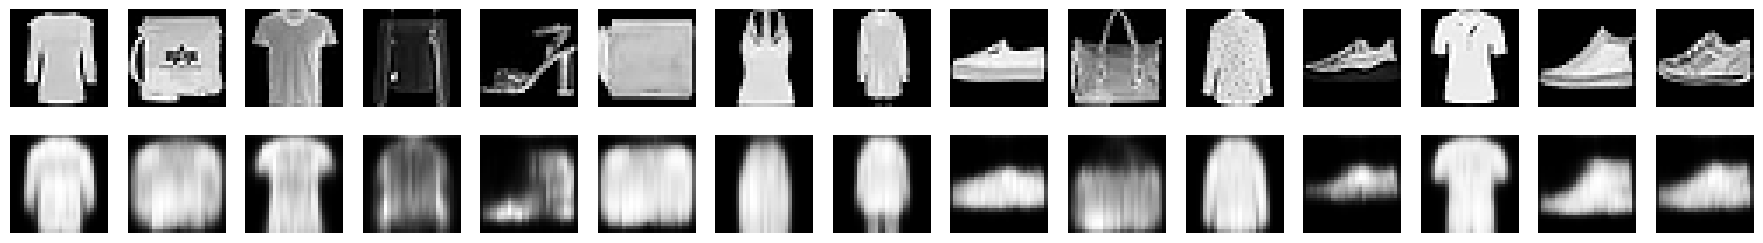

In [53]:
show_reconstructions(recurrent_ae)
plt.show()

# Stacked denoising Autoencoder

In [54]:
# Using Gaussian noise:

tf.random.set_seed(42)
np.random.seed(42)

denoising_encoder = Sequential([
    layers.Input(shape=[28, 28]),
    layers.Flatten(),
    layers.GaussianNoise(0.2),
    layers.Dense(100, activation="selu"),
    layers.Dense(30, activation="selu")
])
denoising_decoder = Sequential([
    layers.Input(shape=[30]),
    layers.Dense(100, activation="selu"),
    layers.Dense(28 * 28, activation="sigmoid"),
    layers.Reshape([28, 28])
])
denoising_ae = Sequential([denoising_encoder, denoising_decoder])

denoising_ae.compile(loss="binary_crossentropy",
                     optimizer=optimizers.SGD(learning_rate=1.0),
                     metrics=[rounded_accuracy])

history = denoising_ae.fit(X_train, X_train,
                           epochs=10,
                           validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.3507 - rounded_accuracy: 0.8771 - val_loss: 0.3194 - val_rounded_accuracy: 0.9058
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.3134 - rounded_accuracy: 0.9090 - val_loss: 0.3100 - val_rounded_accuracy: 0.9149
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.3065 - rounded_accuracy: 0.9147 - val_loss: 0.3047 - val_rounded_accuracy: 0.9161
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.3027 - rounded_accuracy: 0.9180 - val_loss: 0.3009 - val_rounded_accuracy: 0.9209
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3002 - rounded_accuracy: 0.9199 - val_loss: 0.2990 - val_rounded_accuracy: 0.9222
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2983 - rounded_accuracy: 0.9216 - val_loss: 0.2971 - val_rounded_accuracy: 0.9235
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.2969 - rounded_accuracy: 0.9228 - val_loss: 0.2954 - val_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


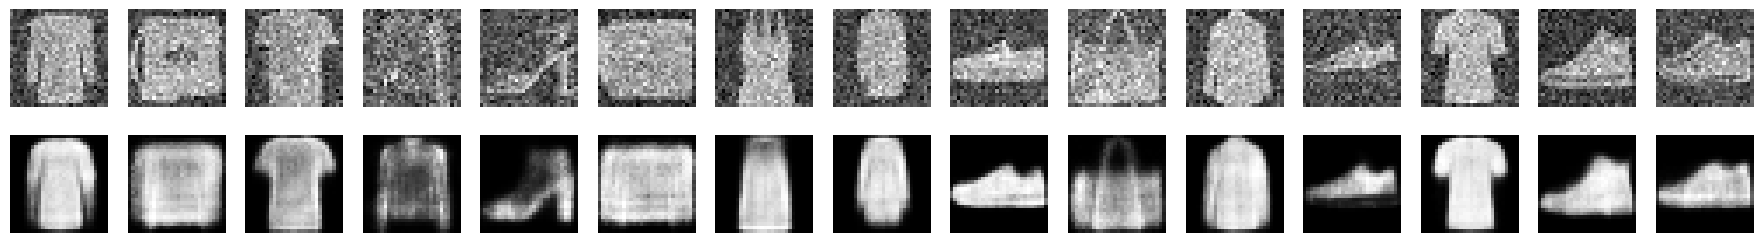

In [55]:
tf.random.set_seed(42)
np.random.seed(42)

noise = layers.GaussianNoise(0.2)
show_reconstructions(denoising_ae, noise(X_valid, training=True))
plt.show()

In [56]:
# Using dropout:
tf.random.set_seed(42)
np.random.seed(42)

dropout_encoder = Sequential([
    layers.Input(shape=[28, 28]),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(100, activation="selu"),
    layers.Dense(30, activation="selu")
])
dropout_decoder = Sequential([
    layers.Input(shape=[30]),
    layers.Dense(100, activation="selu"),
    layers.Dense(28 * 28, activation="sigmoid"),
    layers.Reshape([28, 28])
])
dropout_ae = Sequential([dropout_encoder, dropout_decoder])

dropout_ae.compile(loss="binary_crossentropy",
                   optimizer=optimizers.SGD(learning_rate=1.0),
                   metrics=[rounded_accuracy])

history = dropout_ae.fit(X_train, X_train,
                         epochs=10,
                         validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 0.3569 - rounded_accuracy: 0.8704 - val_loss: 0.3206 - val_rounded_accuracy: 0.9032
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.3183 - rounded_accuracy: 0.9031 - val_loss: 0.3121 - val_rounded_accuracy: 0.9099
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.3114 - rounded_accuracy: 0.9086 - val_loss: 0.3060 - val_rounded_accuracy: 0.9167
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3076 - rounded_accuracy: 0.9117 - val_loss: 0.3021 - val_rounded_accuracy: 0.9194
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.3050 - rounded_accuracy: 0.9139 - val_loss: 0.3019 - val_rounded_accuracy: 0.9206
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3030 - rounded_accuracy: 0.9156 - val_loss: 0.2983 - val_rounded_accuracy: 0.9234
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.3014 - rounded_accuracy: 0.9169 - val_loss: 0.2967 - val_r

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


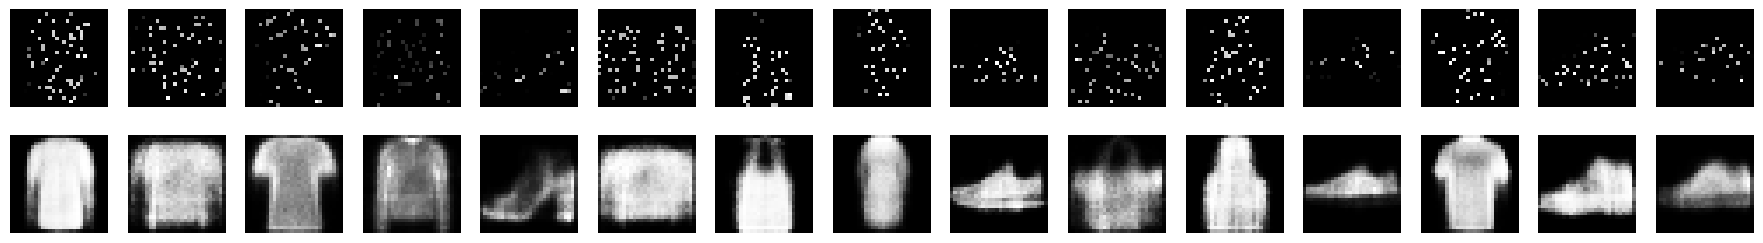

In [61]:
tf.random.set_seed(42)
np.random.seed(42)

dropout = layers.Dropout(0.9) # 90 % dropout !
show_reconstructions(dropout_ae, dropout(X_valid, training=True))